Running SF = 0.01
Rows       : 60,175
Exec Time  : 0.0023s
Running SF = 0.1
Rows       : 600,572
Exec Time  : 0.0050s
Running SF = 0.5
Rows       : 2,999,671
Exec Time  : 0.0090s
Running SF = 1
Rows       : 6,001,215
Exec Time  : 0.0191s


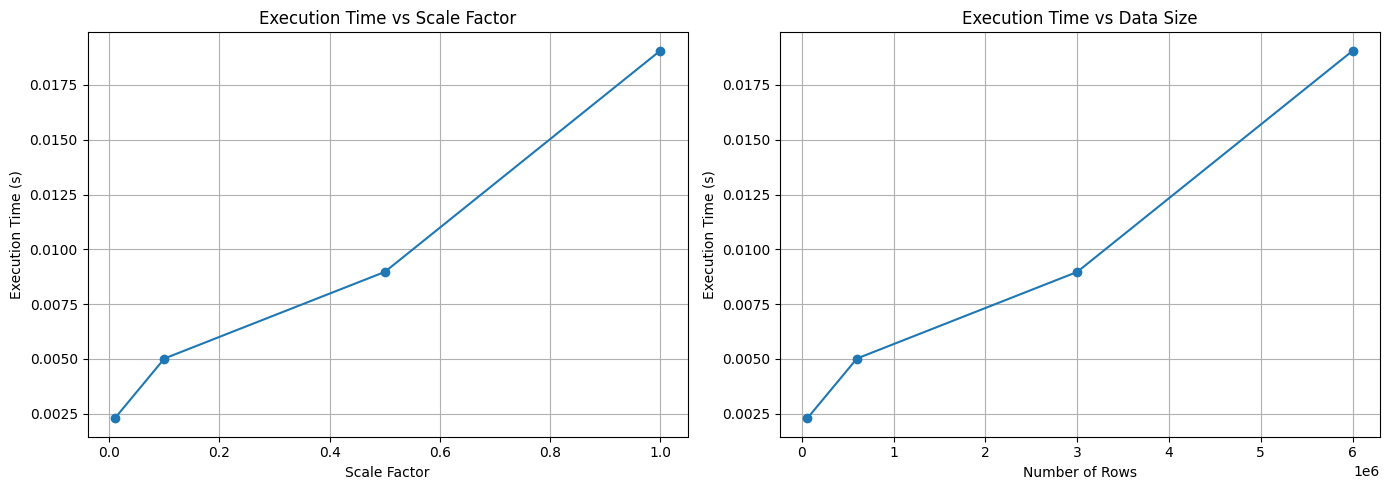

,scale_factor,row_count,execution_time
0,0.01,60175,0.002291
1,0.10,600572,0.005020
2,0.50,2999671,0.008971
3,1.00,6001215,0.019064


In [ ]:
"""
Experiment: DuckDB Performance Across TPC-H Scale Factors

Goal:
Measure how execution time scales with increasing dataset size.

Key Idea:
- Scale Factor (SF) controls dataset size
- Expect near-linear scaling for scan-heavy queries
"""

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time


# -----------------------------
# 1. Define scale factors
# -----------------------------
SCALE_FACTORS = [0.01, 0.1, 0.5, 1]


# -----------------------------
# 2. Query workload
# -----------------------------
QUERY = """
SELECT 
    l_returnflag,
    COUNT(*) AS count,
    SUM(l_quantity) AS sum_qty,
    SUM(l_extendedprice) AS revenue,
    AVG(l_discount) AS avg_discount
FROM lineitem
WHERE l_shipdate <= '1998-09-01'
GROUP BY l_returnflag
"""


# -----------------------------
# 3. Run experiment
# -----------------------------
def run_scale_factor_experiment(scale_factors):

    results = {
        "scale_factor": [],
        "row_count": [],
        "execution_time": []
    }

    for sf in scale_factors:

        print("="*60)
        print(f"Running SF = {sf}")
        print("="*60)

        # New DB per SF (important for isolation)
        con = duckdb.connect(':memory:')
        con.execute("INSTALL tpch")
        con.execute("LOAD tpch")
        con.execute(f"CALL dbgen(sf={sf})")

       
        row_count = con.execute("SELECT COUNT(*) FROM lineitem").fetchone()[0]

       
        con.execute(QUERY).fetchall()

        # Timed execution
        start = time.perf_counter()
        con.execute(QUERY).fetchall()
        exec_time = time.perf_counter() - start

        results["scale_factor"].append(sf)
        results["row_count"].append(row_count)
        results["execution_time"].append(exec_time)

        print(f"Rows       : {row_count:,}")
        print(f"Exec Time  : {exec_time:.4f}s")

        con.close()

    return results



def plot_scale_factor_results(results):

    df = pd.DataFrame(results)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(df["scale_factor"], df["execution_time"], marker='o')
    axes[0].set_xlabel("Scale Factor")
    axes[0].set_ylabel("Execution Time (s)")
    axes[0].set_title("Execution Time vs Scale Factor")
    axes[0].grid()

    axes[1].plot(df["row_count"], df["execution_time"], marker='o')
    axes[1].set_xlabel("Number of Rows")
    axes[1].set_ylabel("Execution Time (s)")
    axes[1].set_title("Execution Time vs Data Size")
    axes[1].grid()

    plt.tight_layout()
    plt.show()

results = run_scale_factor_experiment(SCALE_FACTORS)

plot_scale_factor_results(results)

pd.DataFrame(results)